In [ ]:
import pandas as pd
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
df = pd.read_csv('Final_df.csv')
df.head()

,Question,Response_Number,Response,Score,Answer
0,What is data science?,R1,Data science is a field that combines statisti...,1.00,Data science is an interdisciplinary field tha...
1,What are the key steps in the data science pro...,R1,The key steps in the data science process incl...,0.95,The key steps typically include problem defini...
2,What is the difference between supervised and ...,R1,Supervised learning uses labeled data to train...,1.00,Supervised learning involves training a model ...
3,Explain the bias-variance tradeoff.,R1,The bias-variance tradeoff is a concept in mac...,1.00,The bias-variance tradeoff is the balance betw...
4,What is feature engineering?,R1,Feature engineering is the process of creating...,1.00,Feature engineering is the process of selectin...


In [ ]:
df = df[['Question','Answer','Response','Score']]

In [ ]:
df.head()

,Question,Answer,Response,Score
0,What is data science?,Data science is an interdisciplinary field tha...,Data science is a field that combines statisti...,1.00
1,What are the key steps in the data science pro...,The key steps typically include problem defini...,The key steps in the data science process incl...,0.95
2,What is the difference between supervised and ...,Supervised learning involves training a model ...,Supervised learning uses labeled data to train...,1.00
3,Explain the bias-variance tradeoff.,The bias-variance tradeoff is the balance betw...,The bias-variance tradeoff is a concept in mac...,1.00
4,What is feature engineering?,Feature engineering is the process of selectin...,Feature engineering is the process of creating...,1.00


## Lower Casing

In [ ]:
df['Answer'] = df['Answer'].str.lower()
df['Response'] = df['Response'].str.lower()

## Removing Punctuations

In [ ]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df['Answer'] = df['Answer'].apply(remove_punctuation)
df['Response'] = df['Response'].apply(remove_punctuation)

## Normalizing Data Science Terms

In [ ]:
def normalize_data_science_terms(text):
    replacements = {
        "ml": "machine learning",
        "ai": "artificial intelligence",
        "dl": "deep learning",
        "nlp": "natural language processing",
        "cv": "computer vision",
        "eda": "exploratory data analysis",
        "svm": "support vector machine",
        "cnn": "convolutional neural network",
        "rnn": "recurrent neural network",
        "ann": "artificial neural network",
        "lstm": "long short term memory",
        "xgboost": "extreme gradient boosting",
        "gbm": "gradient boosting machine",
        "knn": "k nearest neighbors",
        "lr": "logistic regression",
        "regression model": "regression",
        "classification model": "classification",
        "scikit-learn": "sklearn",
        "sci-kit learn": "sklearn",
        "tf": "tensorflow",
        "pytorch": "torch",
        "feature engineering": "feature extraction",
        "data wrangling": "data cleaning",
        "data visualization": "data viz",
        "viz": "visualization"
    }
    text = text.lower()
    for key, val in replacements.items():
        text = text.replace(key, val)
    return text

In [ ]:
df['Answer'] = df['Answer'].apply(normalize_data_science_terms)
df['Response'] = df['Response'].apply(normalize_data_science_terms)

## Word Tokenization

In [ ]:
answer_tokens = df['Answer'].str.split()
response_tokens = df['Response'].str.split()

## Removing Stopwords

In [ ]:
stop_words = set(stopwords.words('english'))

answer_tokens = answer_tokens.apply(lambda tokens: [w for w in tokens if w not in stop_words])
response_tokens = response_tokens.apply(lambda tokens: [w for w in tokens if w not in stop_words])

In [ ]:
lemmatizer = WordNetLemmatizer()

answer_tokens = answer_tokens.apply(lambda tokens: [lemmatizer.lemmatize(w) for w in tokens])
response_tokens = response_tokens.apply(lambda tokens: [lemmatizer.lemmatize(w) for w in tokens])


In [ ]:
df['answer_tokens'] = answer_tokens
df['response_tokens'] = response_tokens

In [ ]:
def jaccard_similarity(a, b):
    return len(set(a) & set(b)) / len(set(a) | set(b)) if set(a) | set(b) else 0

keyword_similarity = df.apply(
    lambda row: jaccard_similarity(row['answer_tokens'], row['response_tokens']),
    axis=1
)


In [ ]:
keyword_similarity

,0
0,0.176471
1,0.121951
2,0.342105
3,0.346154
4,0.250000
...,...
2615,0.157895
2616,0.050000
2617,0.142857
2618,0.263158


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

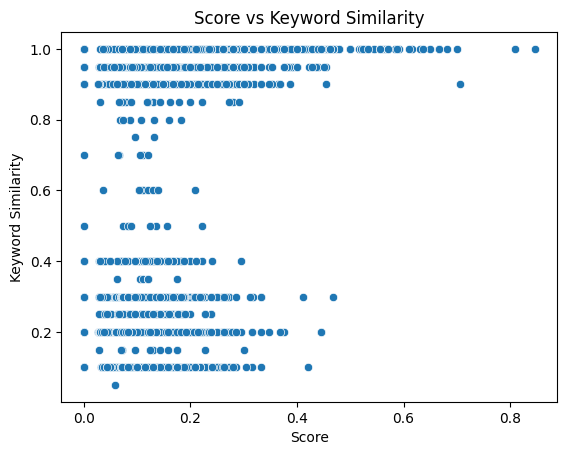

In [ ]:
sns.scatterplot(x=keyword_similarity,y=df['Score'])
plt.title('Score vs Keyword Similarity')
plt.xlabel('Score')
plt.ylabel('Keyword Similarity')
plt.show()

In [ ]:
keyword_similarity.to_csv('keyword_score.csv',index=False)